In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow
import datasets

print("PyArrow:", pyarrow.__version__)
print("Datasets:", datasets.__version__)

PyArrow: 25.0.1
Datasets: 5.0.1


In [3]:
!pip install -U datasets huggingface_hub -q

In [4]:
!pip uninstall -y pyarrow datasets
!pip install -q datasets pyarrow

from datasets import load_dataset
dataset = load_dataset("fancyzhx/dbpedia_14")

Found existing installation: pyarrow 25.0.1
Uninstalling pyarrow-25.0.1:
  Successfully uninstalled pyarrow-25.0.1
Found existing installation: datasets 5.0.1
Uninstalling datasets-5.0.1:
  Successfully uninstalled datasets-5.0.1


In [5]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 560000
    })
    test: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 70000
    })
})


In [6]:
label_names = dataset["train"].features["label"].names
print(label_names)

['Company', 'EducationalInstitution', 'Artist', 'Athlete', 'OfficeHolder', 'MeanOfTransportation', 'Building', 'NaturalPlace', 'Village', 'Animal', 'Plant', 'Album', 'Film', 'WrittenWork']


In [7]:
train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

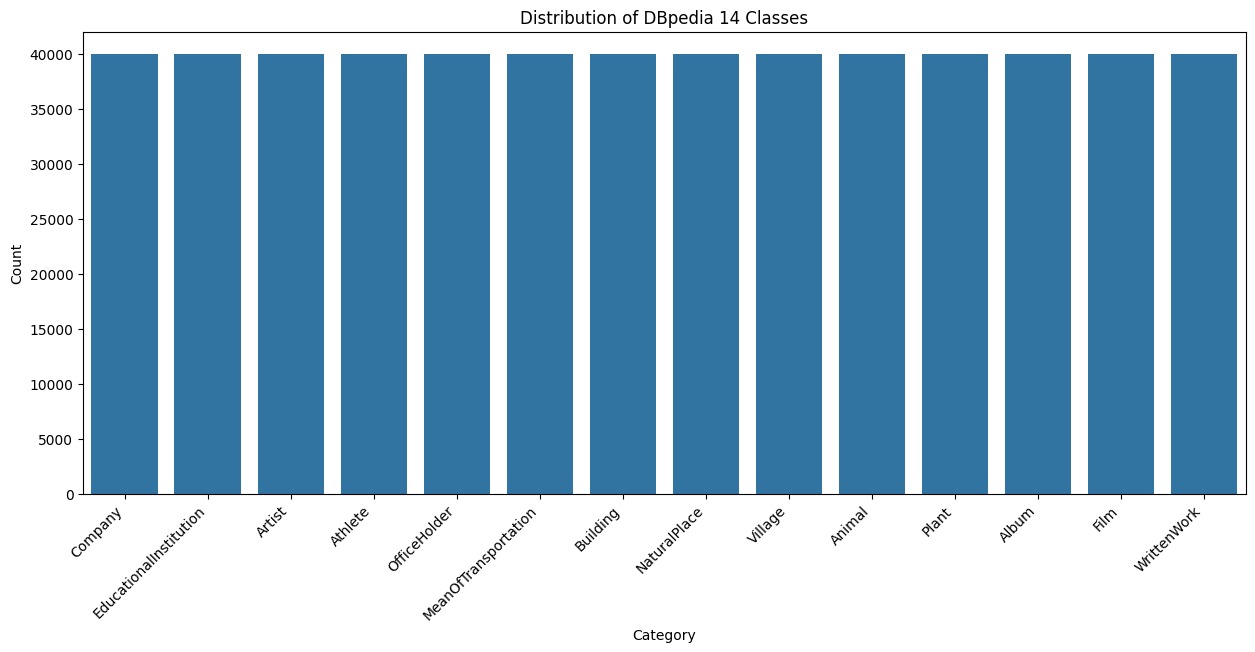

In [8]:
plt.figure(figsize=(15, 6))
sns.countplot(
    x="label",
    data=train_df,
    order=range(len(label_names))
)
plt.xticks(
    ticks=range(len(label_names)),
    labels=label_names,
    rotation=45,
    ha="right"
)
plt.xlabel("Category")
plt.ylabel("Count")
plt.title("Distribution of DBpedia 14 Classes")
plt.show()

In [9]:
train_df.isna().sum()

,0
label,0
title,0
content,0


In [10]:
train_df.head(5)

,label,title,content
0,0,E. D. Abbott Ltd,Abbott of Farnham E D Abbott Limited was a Br...
1,0,Schwan-Stabilo,Schwan-STABILO is a German maker of pens for ...
2,0,Q-workshop,Q-workshop is a Polish company located in Poz...
3,0,Marvell Software Solutions Israel,Marvell Software Solutions Israel known as RA...
4,0,Bergan Mercy Medical Center,Bergan Mercy Medical Center is a hospital loc...


In [11]:
def preprocess(text):
    text = text.lower()
    text = text.replace('\n', ' ')
    text = " ".join(text.split())

    return text

In [12]:
train_df = train_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

In [13]:
test_df = test_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

In [14]:
print(train_df["label"].head(20))

0      0
1      5
2      2
3      9
4      7
5     11
6      2
7      3
8      3
9      6
10     7
11     7
12    12
13    12
14    12
15     4
16     0
17     5
18    10
19     1
Name: label, dtype: int64


In [15]:
X_train = (
    train_df["title"].fillna("") + " " +
    train_df["content"].fillna("")
)
Y_train = train_df["label"]
X_test = (
    test_df["title"].fillna("") + " " +
    test_df["content"].fillna("")
)
Y_test = test_df["label"]

In [16]:
X_train = X_train.apply(preprocess)
X_test = X_test.apply(preprocess)

In [16]:
import numpy as np

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 30000
max_length = 100

tokenize = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

tokenize.fit_on_texts(X_train)

train_sequence = tokenize.texts_to_sequences(X_train)
test_sequence = tokenize.texts_to_sequences(X_test)

padded_train_sequence = pad_sequences(
    train_sequence,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

padded_test_sequence = pad_sequences(
    test_sequence,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

train_labels = np.array(Y_train)
test_labels = np.array(Y_test)

num_classes = len(np.unique(train_labels))
total_vocab_size = len(tokenize.word_index) + 1
vocab_size = min(max_words, total_vocab_size)

print(f"Number of classes: {num_classes}")
print(f"Total words found: {total_vocab_size}")
print(f"Max words allowed: {max_words}")
print(f"Vocabulary size used: {vocab_size}")
print(f"Max sentence length: {padded_train_sequence.shape[1]}")

Number of classes: 14
Total words found: 730802
Max words allowed: 30000
Vocabulary size used: 30000
Max sentence length: 100


In [17]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam

rnn_model = Sequential([

    Embedding(
        input_dim=max_words,
        output_dim=128
    ),

    SimpleRNN(
        units=128,
        dropout=0.2
    ),

    Dense(64, activation='relu'),

    Dropout(0.3),

    Dense(
        num_classes,
        activation='softmax'
    )
])

In [19]:
optimizer = Adam(
    learning_rate=0.001,
    clipnorm=1.0
)

rnn_model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
history = rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_split=0.2,
    epochs=20,
    batch_size=256,
    callbacks=[early_stopping],
    shuffle=True
)
rnn_loss, rnn_accuracy = rnn_model.evaluate(
    padded_test_sequence,
    test_labels
)
print(f"RNN Loss: {rnn_loss:.4f}")
print(f"RNN Accuracy: {rnn_accuracy:.4f}")

Epoch 1/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 38s 19ms/step - accuracy: 0.4899 - loss: 1.4261 - val_accuracy: 0.5720 - val_loss: 1.2356
Epoch 2/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.5066 - loss: 1.4710 - val_accuracy: 0.5186 - val_loss: 1.4328
Epoch 3/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - accuracy: 0.3444 - loss: 1.9219 - val_accuracy: 0.3631 - val_loss: 1.8572
Epoch 4/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.3526 - loss: 1.9031 - val_accuracy: 0.3737 - val_loss: 1.8507
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.5725 - loss: 1.2285
RNN Loss: 1.2285
RNN Accuracy: 0.5725


In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

lstm_model = Sequential([
    Embedding(
        input_dim=max_words,
        output_dim=128
    ),
    LSTM(
        units=128,
        dropout=0.2
    ),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(
        units=num_classes,
        activation='softmax'
    )
])

optimizer = Adam(
    learning_rate=0.001,
    clipnorm=1.0
)

lstm_model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()
history_lstm = lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_split=0.2,
    epochs=20,
    batch_size=256,
    callbacks=[early_stopping],
    shuffle=True
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(
    padded_test_sequence,
    test_labels
)

print(f"\nLSTM Loss: {lstm_loss:.4f}")
print(f"LSTM Accuracy: {lstm_accuracy:.4f}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.1293 - loss: 2.3541 - val_accuracy: 0.1223 - val_loss: 2.4032
Epoch 2/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 36s 21ms/step - accuracy: 0.1267 - loss: 2.3834 - val_accuracy: 0.1685 - val_loss: 2.2041
Epoch 3/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.8079 - loss: 0.5123 - val_accuracy: 0.9821 - val_loss: 0.0736
Epoch 4/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.9848 - loss: 0.0673 - val_accuracy: 0.9859 - val_loss: 0.0610
Epoch 5/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.9897 - loss: 0.0446 - val_accuracy: 0.9860 - val_loss: 0.0597
Epoch 6/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.9926 - loss: 0.0326 - val_accuracy: 0.9865 - val_loss: 0.0628
Epoch 7/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.9942 - loss: 0.0250 - val_accuracy: 0.9861 - val_loss: 0.0679
Epoch 8/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.9957 -

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam

gru_model = Sequential([

    Embedding(
        input_dim=max_words,
        output_dim=128
    ),

    GRU(
        units=128,
        dropout=0.2
    ),

    Dense(64, activation='relu'),

    Dropout(0.3),

    Dense(
        units=num_classes,
        activation='softmax'
    )
])

optimizer = Adam(
    learning_rate=0.001,
    clipnorm=1.0
)

gru_model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

gru_model.summary()

history_gru = gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_split=0.2,
    epochs=20,
    batch_size=256,
    callbacks=[early_stopping],
    shuffle=True
)

gru_loss, gru_accuracy = gru_model.evaluate(
    padded_test_sequence,
    test_labels
)

print(f"\nGRU Loss: {gru_loss:.4f}")
print(f"GRU Accuracy: {gru_accuracy:.4f}")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.0706 - loss: 2.6394 - val_accuracy: 0.0725 - val_loss: 2.6391
Epoch 2/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - accuracy: 0.7048 - loss: 0.8607 - val_accuracy: 0.9825 - val_loss: 0.0686
Epoch 3/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - accuracy: 0.9859 - loss: 0.0597 - val_accuracy: 0.9866 - val_loss: 0.0517
Epoch 4/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - accuracy: 0.9909 - loss: 0.0378 - val_accuracy: 0.9871 - val_loss: 0.0539
Epoch 5/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - accuracy: 0.9935 - loss: 0.0263 - val_accuracy: 0.9868 - val_loss: 0.0583
Epoch 6/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - accuracy: 0.9952 - loss: 0.0190 - val_accuracy: 0.9865 - val_loss: 0.0629
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9867 - loss: 0.0491

GRU Loss: 0.0491
GRU Accuracy: 0.9867


In [23]:
result_df = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
}).sort_values(
    by='Test Accuracy',
    ascending=False
).reset_index(drop=True)

result_df

,Model,Test Loss,Test Accuracy
0,GRU,0.049053,0.986700
1,LSTM,0.060493,0.985543
2,RNN,1.228518,0.572457


In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam

BiGRU = Sequential([

    Embedding(
        input_dim=max_words,
        output_dim=128
    ),

    Bidirectional(
        GRU(128, dropout=0.2)
    ),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(
        num_classes,
        activation='softmax'
    )
])

optimizer = Adam(
    learning_rate=0.001,
    clipnorm=1.0
)

BiGRU.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
BiGRU.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [25]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping_bigru = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [26]:
history_bigru = BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_split=0.2,
    epochs=20,
    batch_size=256,
    callbacks=[early_stopping_bigru],
    shuffle=True
)

Epoch 1/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 57s 31ms/step - accuracy: 0.9297 - loss: 0.2312 - val_accuracy: 0.9835 - val_loss: 0.0608
Epoch 2/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 52s 30ms/step - accuracy: 0.9868 - loss: 0.0536 - val_accuracy: 0.9858 - val_loss: 0.0542
Epoch 3/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 53s 30ms/step - accuracy: 0.9908 - loss: 0.0362 - val_accuracy: 0.9860 - val_loss: 0.0548
Epoch 4/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 82s 30ms/step - accuracy: 0.9935 - loss: 0.0258 - val_accuracy: 0.9856 - val_loss: 0.0615
Epoch 5/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 53s 30ms/step - accuracy: 0.9950 - loss: 0.0187 - val_accuracy: 0.9858 - val_loss: 0.0660


In [27]:
bigru_loss, bigru_accuracy = BiGRU.evaluate(
    padded_test_sequence,
    test_labels
)

print(f"BiGRU Loss: {bigru_loss:.4f}")
print(f"BiGRU Accuracy: {bigru_accuracy:.4f}")

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9864 - loss: 0.0518
BiGRU Loss: 0.0518
BiGRU Accuracy: 0.9864


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

BiGRU_predictions = np.argmax(
    BiGRU.predict(padded_test_sequence),
    axis=1
)

cm = confusion_matrix(test_labels, BiGRU_predictions)

plt.figure(figsize=(15, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='YlOrBr',
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("BiGRU Confusion Matrix")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

In [29]:
sample_texts = [
    "Apple is a multinational technology company that develops smartphones and computers.",

    "Harvard University is a prestigious educational institution located in the United States.",

    "Lionel Messi is a professional football player known for his exceptional skills.",

    "The Beatles were an influential British rock band.",

    "The film received positive reviews and became a commercial success."
]


sample_sequences = tokenize.texts_to_sequences(sample_texts)

sample_padded_sequences = pad_sequences(
    sample_sequences,
    maxlen=100,
    padding='post',
    truncating='post'
)


sample_predictions = np.argmax(
    BiGRU.predict(sample_padded_sequences),
    axis=1
)


for i in range(len(sample_texts)):
    print(f"Text: {sample_texts[i]}")
    print(f"Predicted Category: {label_names[sample_predictions[i]]}\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Text: Apple is a multinational technology company that develops smartphones and computers.
Predicted Category: Company

Text: Harvard University is a prestigious educational institution located in the United States.
Predicted Category: EducationalInstitution

Text: Lionel Messi is a professional football player known for his exceptional skills.
Predicted Category: Athlete

Text: The Beatles were an influential British rock band.
Predicted Category: Album

Text: The film received positive reviews and became a commercial success.
Predicted Category: Film



In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
)
from datasets import Dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

train_hf = Dataset.from_dict({"text": X_train.tolist(), "label": Y_train.tolist()})
test_hf = Dataset.from_dict({"text": X_test.tolist(), "label": Y_test.tolist()})

MODEL_NAME = "distilbert-base-uncased"
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

MAX_LENGTH = 100

def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
    )

train_tok = train_hf.map(tokenize_fn, batched=True)
test_tok = test_hf.map(tokenize_fn, batched=True)

train_tok = train_tok.rename_column("label", "labels")
test_tok = test_tok.rename_column("label", "labels")
train_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

split = train_tok.train_test_split(test_size=0.2, seed=42)
train_split, val_split = split["train"], split["test"]

num_classes = len(label_names)

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=num_classes
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

training_args = TrainingArguments(
    output_dir="./distilbert_dbpedia",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=256,
    per_device_eval_batch_size=128,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=True,
    logging_steps=100,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_split,
    eval_dataset=val_split,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()

distilbert_test_metrics = trainer.evaluate(test_tok)
print(distilbert_test_metrics)

distilbert_row = {
    "Model": "DistilBERT",
    "Accuracy": distilbert_test_metrics["eval_accuracy"],
    "Precision": distilbert_test_metrics["eval_precision"],
    "Recall": distilbert_test_metrics["eval_recall"],
    "F1": distilbert_test_metrics["eval_f1"],
}

def eval_keras_model(model_obj, X, y_true):
    preds = np.argmax(model_obj.predict(X, verbose=0), axis=1)
    acc = accuracy_score(y_true, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, preds, average="macro", zero_division=0
    )
    return acc, precision, recall, f1

rows = [distilbert_row]

for name, mdl in [
    ("RNN", rnn_model),
    ("LSTM", lstm_model),
    ("GRU", gru_model),
    ("BiGRU", BiGRU),
]:
    acc, precision, recall, f1 = eval_keras_model(mdl, padded_test_sequence, test_labels)
    rows.append(
        {"Model": name, "Accuracy": acc, "Precision": precision, "Recall": recall, "F1": f1}
    )

comparison_df = pd.DataFrame(rows).sort_values(by="F1", ascending=False).reset_index(drop=True)
print(comparison_df.to_string(index=False))

best_model_name = comparison_df.iloc[0]["Model"]
print(f"\nBest model by macro F1: {best_model_name}")

if best_model_name == "DistilBERT":
    preds = np.argmax(trainer.predict(test_tok).predictions, axis=1)
    print(classification_report(test_labels, preds, target_names=label_names))

Map:   0%|          | 0/560000 [00:00<?, ? examples/s]

Map:   0%|          | 0/70000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.028846,0.027820,0.992607,0.992615,0.992593,0.992601


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]